# Laptop Price Prediction

In this notebook, we will:
1. Explore the dataset (EDA).
2. Preprocess the data for machine learning.
3. Implement a simple prediction model using Linear Regression.
4. Evaluate model performance.

---


In [62]:
# 📦 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

## Step 1: Load the Dataset
We will load the dataset and look at the first few rows to understand its structure.


In [63]:
# Load the dataset
df = pd.read_csv("laptopPrice.csv")

# Display first 5 rows
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


## Step 2: Basic EDA
We will explore:
- Shape of dataset
- Missing values
- Data types
- Summary statistics
- Correlation of numerical features with Price


In [64]:
# Shape
print("Shape of dataset:", df.shape)

# Info
print("\nInfo:")
print(df.info())

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Summary statistics
df.describe()

Shape of dataset: (823, 19)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating   

,Price,Number of Ratings,Number of Reviews
count,823.000000,823.000000,823.000000
mean,76745.177400,315.301337,37.609964
std,45101.790525,1047.382654,121.728017
min,16990.000000,0.000000,0.000000
25%,46095.000000,0.000000,0.000000
50%,64990.000000,17.000000,2.000000
75%,89636.000000,139.500000,18.000000
max,441990.000000,15279.000000,1947.000000


### Step 2.1: Correlation Heatmap
This will help us understand which numerical features affect the Price most.


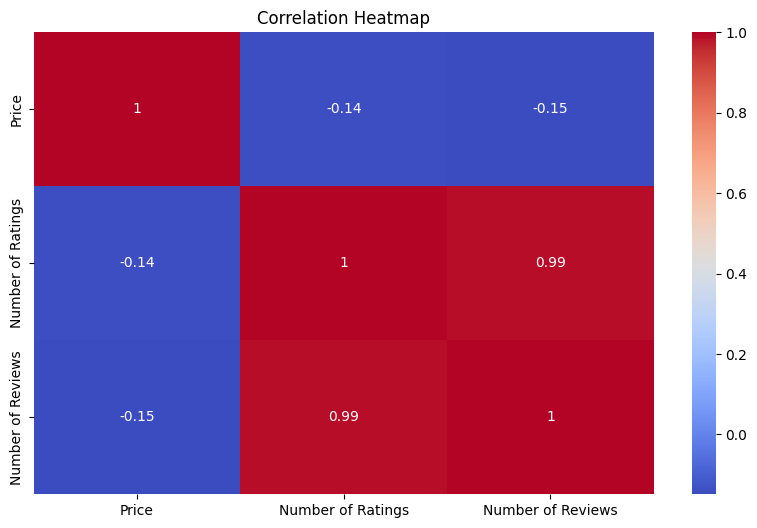

In [65]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Step 3: Data Preprocessing
1. Select features (X) and target (y = Price).
2. Handle categorical columns (convert to numbers using one-hot encoding).
3. Split data into training and test sets.


In [66]:
# Target variable (assuming column name is "Price")
y = df["Price"]

# Features (drop Price)
X = df.drop("Price", axis=1)

# Convert categorical to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 4: Build Prediction Model
We will use **Linear Regression** (a simple algorithm) to predict laptop prices.


In [67]:
# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

## Step 5: Evaluate Model
We will use:
- Mean Squared Error (MSE)
- R² Score (explains variance explained by model)


In [68]:
# Mean Squared Error & R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Custom accuracy (within 20% error margin)
mape = mean_absolute_percentage_error(y_test, y_pred)  # Mean Absolute Percentage Error
accuracy = 100 - (mape * 100)

print("Mean Squared Error:", mse)
print("R² Score:", r2)
print("Accuracy (approx):", accuracy, "%")

Mean Squared Error: 576410115.1504672
R² Score: 0.7042241051300435
Accuracy (approx): 81.83525439538683 %


## Step 6: Visualization of Predictions vs Actuals
We will plot:
1. **Line graph** → Compare actual vs predicted prices across test samples.
2. **Scatter plot** → Show correlation between actual and predicted prices. Perfect predictions will lie on the 45° line.


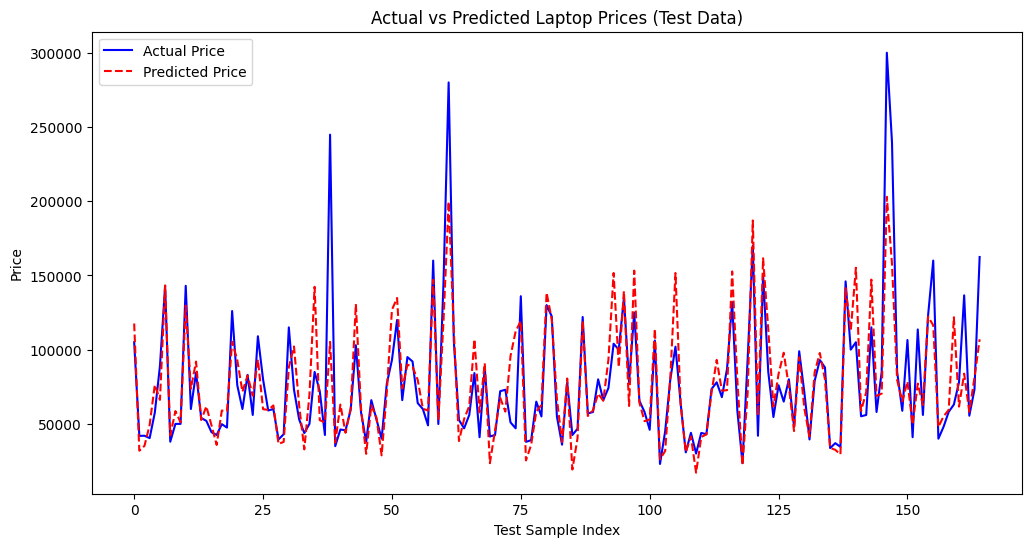

In [69]:
# 📈 Line graph: Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual Price", color="blue")
plt.plot(y_pred, label="Predicted Price", color="red", linestyle="dashed")
plt.title("Actual vs Predicted Laptop Prices (Test Data)")
plt.xlabel("Test Sample Index")
plt.ylabel("Price")
plt.legend()
plt.show()

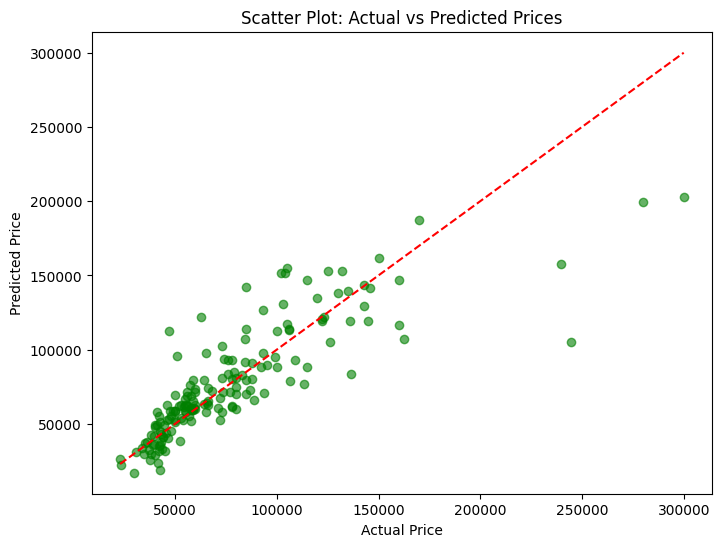

In [70]:
# 📊 Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="green")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="dashed",
)
plt.title("Scatter Plot: Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## Step 7: Test Cases
We will pick a few rows from the test split (`X_test`) and check:
1. The actual price (`y_test`)
2. The predicted price (`y_pred`)


In [71]:
# Convert test set to DataFrame for easy viewing
test_results = pd.DataFrame(
    {"Actual Price": y_test.values, "Predicted Price": y_pred}, index=y_test.index
)

# Show 5 random test cases
test_cases = test_results.sample(5, random_state=42)
print(test_cases)

     Actual Price  Predicted Price
641         33690     33809.078352
380         86990     72695.553643
29          39490     41486.948889
579         63990     79625.637005
535        134990    139332.940806
